In [1]:
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("abhinand05/crop-production-in-india")

print("Dataset Path:", path)
print(os.listdir(path))

100%|██████████| 1.96M/1.96M [00:00<00:00, 119MB/s]

Extracting files...
Dataset Path: /root/.cache/kagglehub/datasets/abhinand05/crop-production-in-india/versions/1
['crop_production.csv']


In [2]:
csv_file = os.path.join(path, "crop_production.csv")  # adjust filename if needed

df = pd.read_csv(csv_file)

print(df.head())
print(df.columns)
print(df.info())

                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
2  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
3  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    
4  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    

                  Crop    Area  Production  
0             Arecanut  1254.0      2000.0  
1  Other Kharif pulses     2.0         1.0  
2                 Rice   102.0       321.0  
3               Banana   176.0       641.0  
4            Cashewnut   720.0       165.0  
Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         -

Create a Yield Column

In [3]:
df = df.dropna(subset=['Area', 'Production'])

df['Yield'] = df['Production'] / df['Area']

#**# Week 3 Charts**

**1. Line Chart**

    Business Question: How has total crop production changed over time?

    Why this chart type: A line chart is ideal for displaying trends over time because it highlights increases, decreases, and long-term patterns across years.

In [5]:
import matplotlib.pyplot as plt

df['Crop_Year'] = pd.to_datetime(df['Crop_Year'], format='%Y')

df['Crop_Year'] = df['Crop_Year'].dt.year

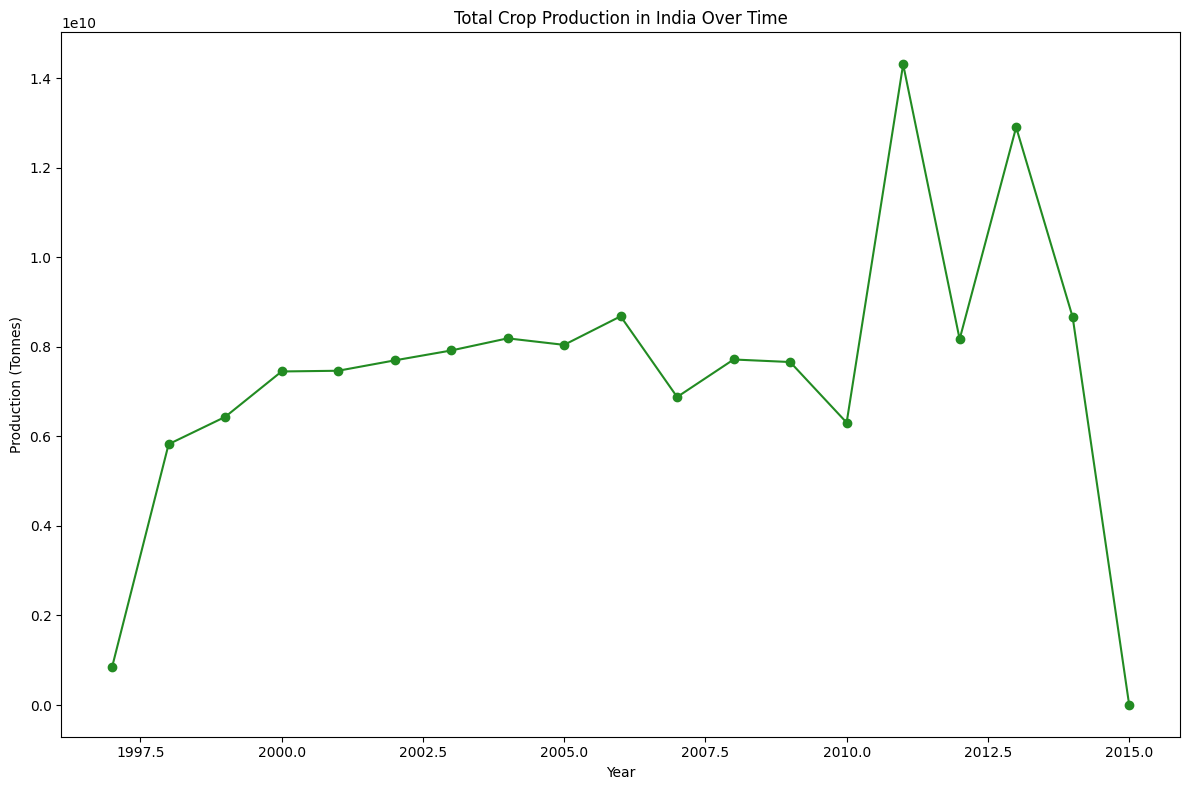

In [15]:
yearly = df.groupby('Crop_Year')['Production'].sum()

plt.figure(figsize=(12,8))

yearly.plot(
    color='forestgreen',
    marker='o'
)

plt.title('Total Crop Production in India Over Time')
plt.xlabel('Year')
plt.ylabel('Production (Tonnes)')
plt.tight_layout()

plt.savefig(
    'W3_Chart1_TBI26100605.png',
    dpi=300,
    bbox_inches='tight'
)


plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

**2. Bar Chart**

    Business Question: Which crops contribute the most production?
    
    Why this chart type: A bar chart allows easy comparison among categories and clearly identifies the highest and lowest producing crops.

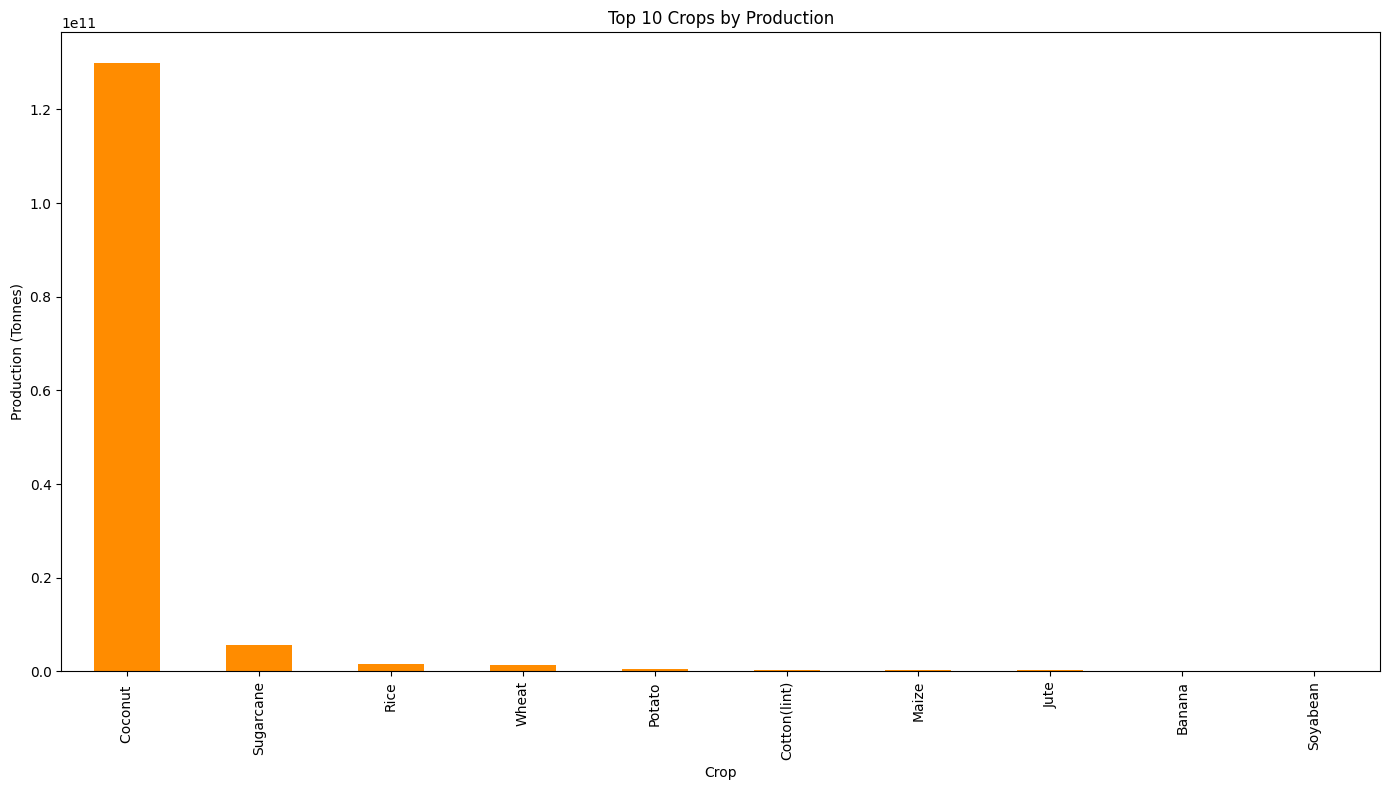

In [16]:
top_crops = (
    df.groupby('Crop')['Production']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,8))

top_crops.plot(
    kind='bar',
    color='darkorange'
)

plt.title('Top 10 Crops by Production')
plt.xlabel('Crop')
plt.ylabel('Production (Tonnes)')
plt.tight_layout()

plt.savefig(
    'W3_Chart2_TBI26100605.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**3. Scatter Plot**

    Business Question: Does larger cultivated area lead to greater production?

    Why this chart type: A scatter plot is the best choice for examining relationships between two numerical variables and identifying patterns or outliers.

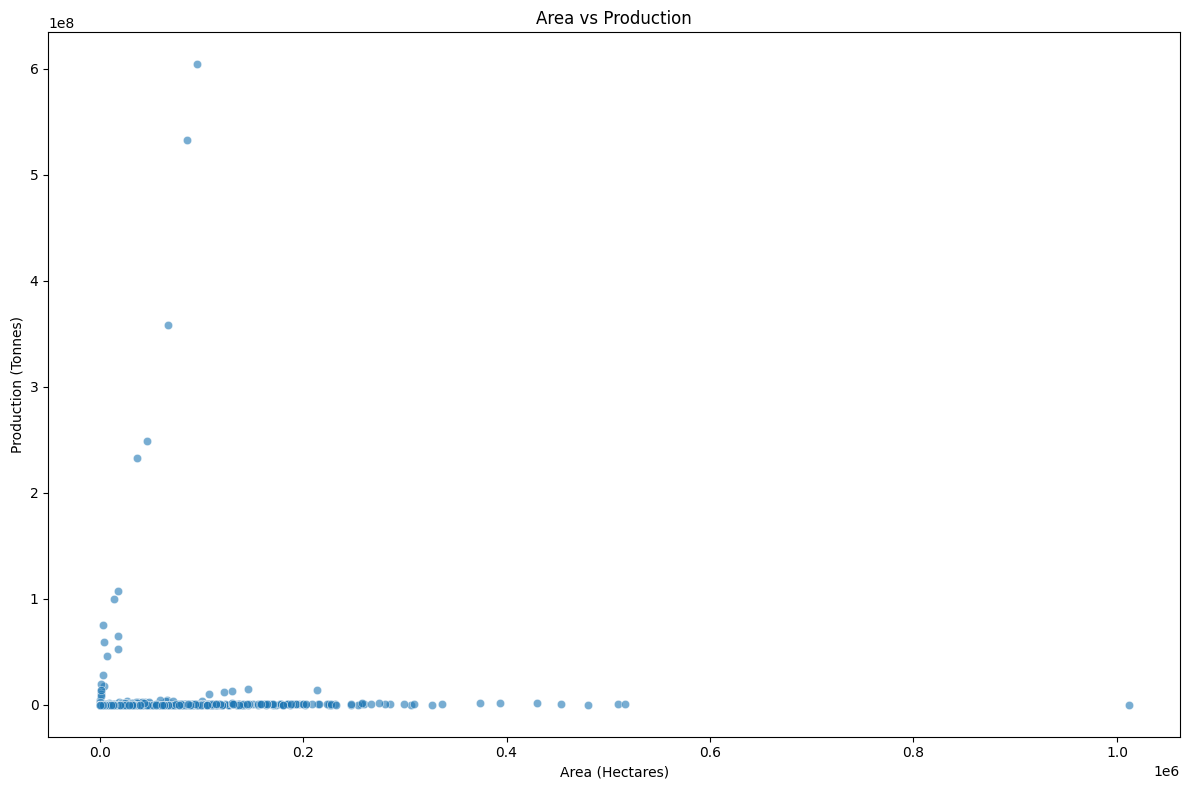

In [17]:
import seaborn as sns

sample = df.sample(5000)

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=sample,
    x='Area',
    y='Production',
    alpha=0.6
)

plt.title('Area vs Production')
plt.xlabel('Area (Hectares)')
plt.ylabel('Production (Tonnes)')
plt.tight_layout()

plt.savefig(
    'W3_Chart3_TBI26100605.png',
    dpi=300,
    bbox_inches='tight'
)


plt.show()

**4. Pie Chart**

    Business Question: What percentage of production comes from major crops?

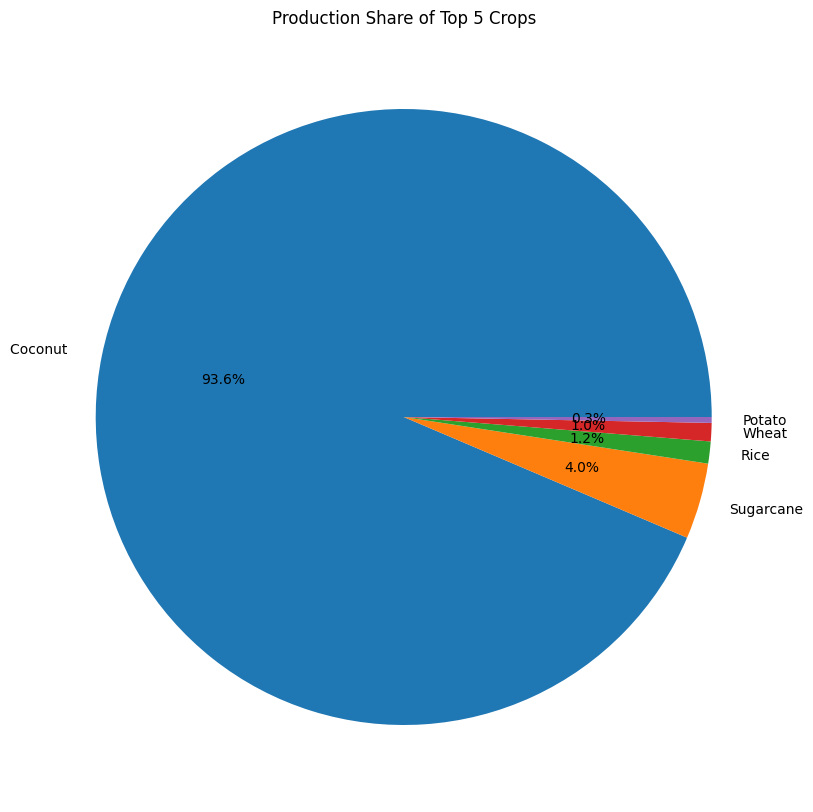

In [18]:
top5 = (
    df.groupby('Crop')['Production']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,10))

plt.pie(
    top5,
    labels=top5.index,
    autopct='%1.1f%%'
)

plt.title('Production Share of Top 5 Crops')

plt.show()

**5. Heatmap**

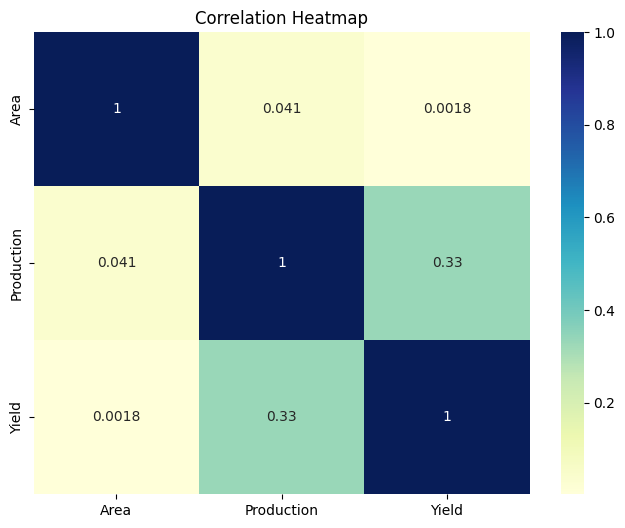

In [19]:
numeric = df[['Area','Production','Yield']]

corr = numeric.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='YlGnBu'
)

plt.title('Correlation Heatmap')

plt.show()